In [56]:
import pandas

In [57]:
df= pandas.read_csv('product_activity.csv')


## 1. Exploración y Limpieza (Quarantine + Recálculo).

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [59]:
df.head()


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile


In [60]:
df.describe()

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [61]:
print('Dimensiones m x n')
df.shape

print('Nulos')
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)

Dimensiones m x n
Nulos
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


In [62]:
total_duplicados = df.duplicated().sum()
print(total_duplicados)

172


In [63]:
df['country'].value_counts()

country
US    1928
BR    1656
AR    1199
PY     859
MX     835
CL     569
ES     568
CO     510
PE     403
UY     255
Name: count, dtype: int64

In [64]:
#elementos unicos
df['plan_type'].nunique()

19

In [65]:
df['plan_type'].value_counts()

plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

In [66]:
df['device_type'].nunique()

6

In [67]:
df['device_type'].value_counts()

device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

In [68]:
df['post_category'].value_counts()

post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  

In [69]:
df['post_category'].nunique()

53

Normalizando plan_type

In [70]:
df['plan_type_clean']=df['plan_type'].str.strip().str.lower()
df['plan_type_clean'].value_counts()

plan_type_clean
free           6768
pro            1667
enterprise      344
premium           1
vip               1
enterprise+       1
Name: count, dtype: int64

In [71]:
plan_type_map={
    'enterprise+':'enterprise'
}
df['plan_type_clean']=df['plan_type_clean'].replace(plan_type_map)

In [72]:
df['plan_type_clean'].value_counts()

plan_type_clean
free          6768
pro           1667
enterprise     345
premium          1
vip              1
Name: count, dtype: int64

In [73]:
plan_type_map={
    'pro':'pro',
    'free':'free',
    'enterprise':'enterprise'
}
df['plan_type_clean']=df['plan_type_clean'].map(plan_type_map)

In [74]:
df['plan_type_clean'].value_counts()

plan_type_clean
free          6768
pro           1667
enterprise     345
Name: count, dtype: int64

In [75]:
plan_type_fuera= df['plan_type_clean'].isnull()
plan_type_fuera

0       False
1       False
2       False
3       False
4       False
        ...  
8777    False
8778    False
8779    False
8780    False
8781    False
Name: plan_type_clean, Length: 8782, dtype: bool

Normalizar device_type

In [76]:
device_type_map={
    'web':'web',
    'mobile':'mobile',
    'desktop': 'desktop'
}

df['device_type_clean']=df['device_type'].map(device_type_map)
df['device_type_clean'].value_counts()

device_type_clean
web        4416
mobile     3761
desktop     602
Name: count, dtype: int64

In [77]:
device_type_fuera=df['device_type_clean'].isnull()

In [78]:
df['post_category_clean']=df['post_category'].str.strip().str.lower()
df['post_category_clean'].value_counts()

post_category_clean
tech         1380
life         1033
sports        972
science       855
finance       851
gaming        817
music         683
education     669
health        666
travel        500
tehc           50
sport          42
sciense        42
gamming        40
sporst         35
finanse        32
educatoin      31
healt          28
lfe            21
trvael         16
musc           16
politics        1
mistery         1
sp0rts          1
Name: count, dtype: int64

In [79]:
post_category_map= {
    "tech":"tech", 
    "life": "life", 
    "sports": "sports", 
    "science": "science", 
    "finance": "finance", 
    "gaming": "gaming", 
    "music": "music", 
    "health": "health", 
    "education": "education", 
    "travel": "travel",
    "tehc":"tech", 
    "lfe": "life", 
    "sport": "sports", 
    "sp0rts": "sports", 
    "sporst": "sports", 
    "finanse": "finance", 
    "sciense": "science", 
    "musc": "music", 
    "healt": "health", 
    "educatoin": "education", 
    "trvael": "travel",
    "gamming": "gaming"
}
df['post_category_clean']=df['post_category_clean'].replace(post_category_map)
df['post_category_clean'].value_counts()

post_category_clean
tech         1430
life         1054
sports       1050
science       897
finance       883
gaming        857
education     700
music         699
health        694
travel        516
politics        1
mistery         1
Name: count, dtype: int64

In [80]:
post_category_map= {
    "tech":"tech", 
    "life": "life", 
    "sports": "sports", 
    "science": "science", 
    "finance": "finance", 
    "gaming": "gaming", 
    "music": "music", 
    "health": "health", 
    "education": "education", 
    "travel": "travel"
}

df['post_category_clean']=df['post_category_clean'].map(post_category_map)

df['post_category_clean'].value_counts()


post_category_clean
tech         1430
life         1054
sports       1050
science       897
finance       883
gaming        857
education     700
music         699
health        694
travel        516
Name: count, dtype: int64

In [81]:
post_category_fuera=df['post_category_clean'].isnull()
post_category_fuera

0       False
1       False
2       False
3       False
4       False
        ...  
8777    False
8778    False
8779    False
8780    False
8781    False
Name: post_category_clean, Length: 8782, dtype: bool

In [82]:
print(plan_type_fuera.sum())     
print(device_type_fuera.sum())    
print(post_category_fuera.sum()) 

2
3
2


Quarantine

In [83]:
q_plan = df.loc[plan_type_fuera].copy()
q_plan['reason_code'] = 'plan_type_out_of_dictionary'

q_device = df.loc[device_type_fuera].copy()
q_device['reason_code'] = 'device_type_out_of_dictionary'

q_category = df.loc[post_category_fuera].copy()
q_category['reason_code'] = 'post_category_out_of_dictionary'

print(q_category)
print(q_device)
print(q_plan)

     user_id           created_at country plan_type  user_age   post_id  \
8775  U20004  2024-11-20T14:30:00      AR       pro      41.0  P0099004   
8776  U20005  2025-06-01T00:00:00      CL       vip      27.0  P0099005   

     post_category      post_created_at  votes_received  user_total_posts  \
8775      politics  2024-11-25T09:00:00               6                 7   
8776       mistery  2025-06-02T00:00:00               3                 1   

      days_since_signup device_type plan_type_clean device_type_clean  \
8775                  5     desktop             pro           desktop   
8776                  1     console             NaN               NaN   

     post_category_clean                      reason_code  
8775                 NaN  post_category_out_of_dictionary  
8776                 NaN  post_category_out_of_dictionary  
     user_id           created_at country plan_type  user_age   post_id  \
8774  U20003  2025-01-05T08:00:00      US      free      22.0  P009

In [84]:
q_device

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,plan_type_clean,device_type_clean,post_category_clean,reason_code
8774,U20003,2025-01-05T08:00:00,US,free,22.0,P0099003,health,2025-01-07T18:00:00,1,2,2,tablet,free,NaN,health,device_type_out_of_dictionary
8776,U20005,2025-06-01T00:00:00,CL,vip,27.0,P0099005,mistery,2025-06-02T00:00:00,3,1,1,console,NaN,NaN,NaN,device_type_out_of_dictionary
8781,U20010,2025-09-01T05:05:05,ES,free,NaN,P0099010,tech,2025-09-02T05:05:05,9,1,1,phone,free,NaN,tech,device_type_out_of_dictionary


In [85]:
df[df['device_type_clean'].isnull()] 

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,plan_type_clean,device_type_clean,post_category_clean
8774,U20003,2025-01-05T08:00:00,US,free,22.0,P0099003,health,2025-01-07T18:00:00,1,2,2,tablet,free,NaN,health
8776,U20005,2025-06-01T00:00:00,CL,vip,27.0,P0099005,mistery,2025-06-02T00:00:00,3,1,1,console,NaN,NaN,NaN
8781,U20010,2025-09-01T05:05:05,ES,free,NaN,P0099010,tech,2025-09-02T05:05:05,9,1,1,phone,free,NaN,tech


In [86]:
df['created_at_dt']=pandas.to_datetime(df['created_at'], errors='coerce')
df['post_created_at_dt']=pandas.to_datetime(df['post_created_at'], errors='coerce')

fechas_no_parseadas=  df['created_at_dt'].isnull() | df['post_created_at_dt'].isnull()

print(fechas_no_parseadas.sum())


2


In [87]:
fechas_no_parseadas

0       False
1       False
2       False
3       False
4       False
        ...  
8777    False
8778     True
8779    False
8780    False
8781    False
Length: 8782, dtype: bool

In [88]:
df[df['created_at_dt'].isnull() | df['post_created_at_dt'].isnull()]

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,plan_type_clean,device_type_clean,post_category_clean,created_at_dt,post_created_at_dt
8772,U20001,2025-02-30T10:00:00,PY,pro,29.0,P0099001,tech,2025-03-01T10:00:00,4,3,1,web,pro,web,tech,NaT,2025-03-01 10:00:00
8778,U20007,2025-03-15T12:00:00,MX,enterprise,38.0,P0099007,science,2025-99-99T00:00:00,5,10,10,web,enterprise,web,science,2025-03-15 12:00:00,NaT


In [89]:
post_antes_signup=df['post_created_at_dt']< df['created_at_dt']
post_antes_signup.sum()

np.int64(100)

In [90]:
q_fechas_ilogica=df[post_antes_signup].copy()
q_fechas_ilogica['reason_code'] = 'post_before_signup'

q_fechas_invalidas = df[fechas_no_parseadas].copy()
q_fechas_invalidas['reason_code'] = 'unparseable_date'

In [91]:
df['days_since_signup_calculo']=(df['post_created_at_dt']-df['created_at_dt']).dt.days
no_coincide=df['days_since_signup_calculo']!=df['days_since_signup']
print(no_coincide.sum(),no_coincide.sum()/len(df)*100, '%')

4479 51.002049647005244 %


In [92]:
fechas_invalidas=fechas_no_parseadas | post_antes_signup
q_fechas=df[fechas_invalidas].copy()
q_fechas['reason_code'] = q_fechas.apply(lambda r: 'unparseable_date' if pandas.isnull(r['created_at_dt']) or pandas.isnull(r['post_created_at_dt'])
    else 'post_before_signup',axis=1)
q_fechas

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type,plan_type_clean,device_type_clean,post_category_clean,created_at_dt,post_created_at_dt,days_since_signup_calculo,reason_code
22,U01754,2025-01-17T07:05:21,US,free,39.0,P0007502,sports,2024-12-18T16:05:21,3,6,0,web,free,web,sports,2025-01-17 07:05:21,2024-12-18 16:05:21,-30.0,post_before_signup
170,U00707,2024-10-07T17:32:12,MX,pro,27.0,P0003002,gaming,2024-09-27T12:32:12,13,11,0,mobile,pro,mobile,gaming,2024-10-07 17:32:12,2024-09-27 12:32:12,-11.0,post_before_signup
204,U00503,2025-01-13T13:27:33,US,FREE,16.0,P0002095,health,2024-12-14T01:27:33,7,9,0,web,free,web,health,2025-01-13 13:27:33,2024-12-14 01:27:33,-31.0,post_before_signup
208,U01763,2024-12-02T12:42:25,BR,free,39.0,P0007543,music,2024-11-08T11:42:25,5,13,0,web,free,web,music,2024-12-02 12:42:25,2024-11-08 11:42:25,-25.0,post_before_signup
288,U01122,2024-04-28T09:03:25,US,pro,22.0,P0004783,education,2024-03-29T16:03:25,11,6,0,mobile,pro,mobile,education,2024-04-28 09:03:25,2024-03-29 16:03:25,-30.0,post_before_signup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608,U01378,2025-06-19T18:02:45,US,pro,26.0,P0005902,travel,2025-05-20T09:02:45,8,22,0,mobile,pro,mobile,travel,2025-06-19 18:02:45,2025-05-20 09:02:45,-31.0,post_before_signup
8646,U00243,2025-02-03T13:41:27,PY,free,35.0,P0001060,finance,2025-01-31T12:41:27,2,15,0,mobile,free,mobile,finance,2025-02-03 13:41:27,2025-01-31 12:41:27,-4.0,post_before_signup
8772,U20001,2025-02-30T10:00:00,PY,pro,29.0,P0099001,tech,2025-03-01T10:00:00,4,3,1,web,pro,web,tech,NaT,2025-03-01 10:00:00,NaN,unparseable_date
8777,U20006,2025-05-10T00:00:00,PY,free,30.0,P0099006,travel,2025-05-09T23:00:00,2,4,0,web,free,web,travel,2025-05-10 00:00:00,2025-05-09 23:00:00,-1.0,post_before_signup


In [93]:
quarantine = pandas.concat([
    q_plan, q_device, q_category,
    q_fechas
])


reason_codes_unidos = quarantine.groupby('post_id')['reason_code'].apply(
    lambda x: '; '.join(x.unique())
)


quarantine = quarantine.drop_duplicates(subset='post_id').copy()


quarantine['reason_code'] = quarantine['post_id'].map(reason_codes_unidos)

print(len(quarantine))
print(quarantine['reason_code'].value_counts())

102
reason_code
post_before_signup                                                                             95
device_type_out_of_dictionary                                                                   2
unparseable_date                                                                                2
plan_type_out_of_dictionary                                                                     1
plan_type_out_of_dictionary; device_type_out_of_dictionary; post_category_out_of_dictionary     1
post_category_out_of_dictionary                                                                 1
Name: count, dtype: int64


In [94]:
df_core = df[~df['post_id'].isin(quarantine['post_id'])].copy()
df_core = df_core.drop_duplicates()
print(len(df_core))

8508


In [95]:
print(len(df))                          
print(len(df_core) + len(quarantine))  

8782
8610


In [96]:
print('Filas RAW:', len(df))
print('Filas CORE:', len(df_core))
print('% Quarantine:', round(len(quarantine) / len(df) * 100, 2))
print('Duplicados removidos:', total_duplicados)
print('% mismatch fechas:', round(no_coincide.sum() / len(df) * 100, 2))

Filas RAW: 8782
Filas CORE: 8508
% Quarantine: 1.16
Duplicados removidos: 172
% mismatch fechas: 51.0


## 2. Data Quality Report

El dataset original contenía **8782 filas** (una por post). Antes de analizar, se aplicó un proceso de limpieza con los siguientes resultados:

- **Duplicados exactos removidos:** 172 filas (1.96%), correspondientes a registros idénticos en todas sus columnas.
- **Filas enviadas a quarantine:** 102 filas (1.16%), por no cumplir alguna regla de calidad:
  - `plan_type`, `device_type` o `post_category` fuera del diccionario válido
  - Fechas no parseables (`created_at` o `post_created_at` inválidas)
  - Posts publicados antes de la fecha de signup del usuario (95 de los 102 casos — la causa más frecuente)
  - Un caso combinó tres motivos a la vez (plan, dispositivo y categoría inválidos simultáneamente)
- **Dataset final (CORE):** 8508 filas, un **96.9%** del total original, listo para el análisis.
- **Columna `days_since_signup`:** al recalcularla a partir de las fechas reales, **el 51% de las filas no coincidía** con el valor original del dataset. Por ese motivo, todo el análisis posterior usa `days_since_signup_calculo` en lugar de la columna original, que resultó no confiable.

En conjunto, la limpieza retuvo el 96.9% de los datos originales, priorizando conservar información válida por sobre eliminar en exceso — consistente con el criterio de "limpiar con criterio, no perfección" que pide el challenge.

## 3. Métricas, Visualización y Segmentación.

In [97]:
usuarios_por_plan =df_core.groupby('plan_type_clean')['user_id'].nunique()
print(usuarios_por_plan)


plan_type_clean
enterprise      83
free          1545
pro            367
Name: user_id, dtype: int64


In [98]:
posts_por_pais=df_core.groupby('country')['post_id'].count()
print(posts_por_pais)

country
AR    1168
BR    1600
CL     552
CO     489
ES     546
MX     802
PE     393
PY     837
US    1873
UY     248
Name: post_id, dtype: int64


In [99]:
posts_por_categoria=df_core.groupby('post_category_clean')['post_id'].count()
posts_por_dispositivo=df_core.groupby('device_type_clean')['post_id'].count()

print(posts_por_categoria)
print()
print(posts_por_dispositivo)

post_category_clean
education     682
finance       853
gaming        833
health        673
life         1034
music         673
science       870
sports       1017
tech         1381
travel        492
Name: post_id, dtype: int64

device_type_clean
desktop     582
mobile     3656
web        4270
Name: post_id, dtype: int64


In [100]:
df_core['device_type_clean'].value_counts()

device_type_clean
web        4270
mobile     3656
desktop     582
Name: count, dtype: int64

In [101]:
votos_por_plan = df_core.groupby('plan_type_clean')['votes_received'].agg(['mean','median'])
print(votos_por_plan)

                     mean  median
plan_type_clean                  
enterprise       7.547904     7.0
free             6.692706     6.0
pro              7.654014     7.0


In [102]:
votos_por_plan_percentiles = df_core.groupby('plan_type_clean')['votes_received'].quantile([0.25,0.5,0.75]).unstack()
print(votos_por_plan_percentiles)
# tambien se puede usar describe()

                 0.25  0.50  0.75
plan_type_clean                  
enterprise        4.0   7.0  10.0
free              3.0   6.0   9.0
pro               4.0   7.0  10.0


In [103]:
votos_por_pais=df_core.groupby('country')['votes_received'].agg(['mean','median'])
votos_por_categoria=df_core.groupby('post_category_clean')['votes_received'].agg(['mean','median'])
votos_por_dispositivos=df_core.groupby('device_type_clean')['votes_received'].agg(['mean','median'])

print(votos_por_pais)
print()
print(votos_por_categoria)
print()
print(votos_por_dispositivos)


             mean  median
country                  
AR       6.771404     6.0
BR       6.889375     6.0
CL       7.311594     6.0
CO       7.308793     6.0
ES       6.978022     6.0
MX       6.962594     6.0
PE       6.547074     6.0
PY       6.600956     6.0
US       6.973305     6.0
UY       6.762097     6.0

                         mean  median
post_category_clean                  
education            6.781525     6.0
finance              6.978898     6.0
gaming               7.186074     6.0
health               6.456166     6.0
life                 6.173114     5.0
music                6.286776     5.0
science              7.544828     6.0
sports               6.573255     6.0
tech                 7.687183     7.0
travel               6.878049     6.0

                       mean  median
device_type_clean                  
desktop            7.020619     6.0
mobile             6.828228     6.0
web                6.960656     6.0


Calcular promedio de votos por plan y posts por usuario. Obligatorio: Explicar qué significa la unidad de análisis y qué sesgos (outliers) pueden existir.

In [104]:
promedio_votos_por_plan = df_core.groupby('plan_type_clean')['votes_received'].mean()
promedio_posts_por_usuario=df_core.groupby('user_id')['post_id'].count().mean()
print(promedio_votos_por_plan)
print()
print(promedio_posts_por_usuario)


plan_type_clean
enterprise    7.547904
free          6.692706
pro           7.654014
Name: votes_received, dtype: float64

4.264661654135338


Unidad de análisis: cada fila de df_core representa un post, no un usuario. Un promedio calculado directamente sobre votes_received o sobre el conteo de posts pondera más a los usuarios que publican mucho — un usuario con 39 posts pesa 39 veces más que uno con 1 solo post.

Sesgo de outliers: el promedio de posts por usuario es 4.26, pero la mediana es 3.0, y el máximo llega a 39. La desviación estándar (4.10) es casi igual a la media, lo que confirma alta dispersión. Esto indica que la actividad está concentrada en un grupo pequeño de usuarios muy activos que elevan el promedio por encima de lo que representa al usuario típico.

In [105]:
print(df_core.groupby('user_id')['post_id'].count().describe())
posts_por_usuario=df_core.groupby('user_id')['post_id'].count()
print('Mediana:', posts_por_usuario.median())

count    1995.000000
mean        4.264662
std         4.096520
min         1.000000
25%         1.500000
50%         3.000000
75%         6.000000
max        39.000000
Name: post_id, dtype: float64
Mediana: 3.0


4.4 Evento vs Usuario
Calcular promedio de votos por fila y promedio de votos agrupado por usuario. Explicar por qué difieren.

La diferencia es que votos por fila es lo mismo que votos por post ya que cada fila representa un post, entonces el promedio de votos por fila me dice cuantos votos lleva cada post en promedio, y por otro lado el promedio de votos por usuario me dice cuanto votos recibe cun usuario en promedio

In [106]:
promedio_votos_por_fila=df_core['votes_received'].mean()
promedio_votos_por_usuario=df_core.groupby('user_id')['votes_received'].sum().mean()
print(promedio_votos_por_fila)
print(promedio_votos_por_usuario)

6.907851433944523
29.45964912280702


mejorarr markdown anterior!!!!!!
El promedio por fila (6.91) representa cuántos votos recibe, en promedio, un post individual, sin importar quién lo publicó. El promedio por usuario representa cuántos votos acumula, en promedio, un usuario sumando todos sus posts. Como los usuarios publican distinta cantidad de posts (de 1 a 39), estos dos promedios difieren: el promedio por usuario tiende a ser más alto, porque los usuarios con más posts acumulan más votos en total, aunque cada post individual no necesariamente reciba más votos que el promedio general.

Concentración y Temporalidad
Concentración: ¿Qué % de posts/votos viene del top 1% de usuarios?


In [107]:
#votos_por_usuario=df_core.groupby('user_id')['votes_received'].sum()
#posts_por_usuario=df_core.groupby('user_id')['post_id'].count()
votos_posts_por_usuario=df_core.groupby('user_id').agg({'post_id': 'count', 'votes_received':'sum'}).sort_values(
    by=['post_id','votes_received'], ascending=False).copy()
porcentaje_1=round(df_core['user_id'].nunique()*0.01)
if porcentaje_1==0:
    porcentaje_1=porcentaje_1+1
top1=votos_posts_por_usuario.head(porcentaje_1).copy()
print("% de posts/votos del top 1% de usuarios")
porc_votos= top1['votes_received'].sum()/votos_posts_por_usuario['votes_received'].sum()
porc_posts= top1['post_id'].sum()/votos_posts_por_usuario['post_id'].sum()
print(f'posts: {round(porc_posts*100,2)} %')
print(f'votos: {round(porc_votos*100,2)} %')


% de posts/votos del top 1% de usuarios
posts: 6.03 %
votos: 6.04 %


Tendencia: Actividad y engagement por semana/mes.

In [108]:
df_core['mes']=df_core['post_created_at_dt'].dt.to_period('M')
actividad_por_mes=df_core.groupby('mes')['post_id'].count()
actividad_por_mes

mes
2024-01    195
2024-02    370
2024-03    387
2024-04    394
2024-05    456
2024-06    389
2024-07    380
2024-08    388
2024-09    304
2024-10    353
2024-11    364
2024-12    374
2025-01    398
2025-02    299
2025-03    340
2025-04    382
2025-05    354
2025-06    316
2025-07    349
2025-08    372
2025-09    372
2025-10    287
2025-11    294
2025-12    391
Freq: M, Name: post_id, dtype: int64

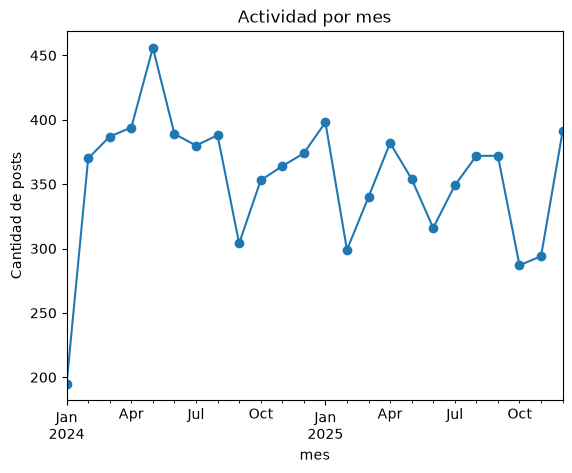

In [109]:
import matplotlib.pyplot as plt

actividad_por_mes.plot(kind='line', marker='o', title='Actividad por mes')
plt.ylabel('Cantidad de posts')
plt.show()

In [110]:
df_core['semana']=df_core['post_created_at_dt'].dt.to_period('W')
actividad_por_semana=df_core.groupby('semana')['post_id'].count()
actividad_por_semana

semana
2024-01-01/2024-01-07    10
2024-01-08/2024-01-14    28
2024-01-15/2024-01-21    60
2024-01-22/2024-01-28    67
2024-01-29/2024-02-04    67
                         ..
2025-12-01/2025-12-07    86
2025-12-08/2025-12-14    85
2025-12-15/2025-12-21    82
2025-12-22/2025-12-28    94
2025-12-29/2026-01-04    44
Freq: W-SUN, Name: post_id, Length: 105, dtype: int64

In [111]:

engagement_por_mes=df_core.groupby('mes')['votes_received'].mean()
engagement_por_mes

mes
2024-01    7.056410
2024-02    7.040541
2024-03    6.627907
2024-04    6.979695
2024-05    6.800439
2024-06    6.776350
2024-07    7.134211
2024-08    6.703608
2024-09    6.677632
2024-10    7.237960
2024-11    6.552198
2024-12    6.791444
2025-01    6.841709
2025-02    7.096990
2025-03    6.823529
2025-04    6.717277
2025-05    7.251412
2025-06    6.607595
2025-07    6.719198
2025-08    7.201613
2025-09    7.193548
2025-10    7.191638
2025-11    6.942177
2025-12    6.971867
Freq: M, Name: votes_received, dtype: float64

## 4. Product Decisions y Conclusiones


¿Qué segmento priorizarías y por qué?
Priorizaría el segmento pro: aunque tiene solo 367 usuarios (frente a los 1545 de free), genera el mayor engagement promedio por post (7.65 votos, contra 6.69 de free). Esto sugiere que son usuarios que producen mejor contenido o están más comprometidos con la plataforma, pero representan una base pequeña — hay una oportunidad de crecer este segmento sin perder su calidad de engagement.

Como respaldo adicional, device_type muestra que web (4270) y mobile (3656) concentran casi toda la actividad frente a desktop (582), así que cualquier iniciativa para el segmento pro debería priorizar mobile/web, no desktop.

¿Qué parte del tablero "mentía" antes de limpiar?
La columna days_since_signup era la parte más engañosa del tablero: al recalcularla con las fechas reales (days_since_signup_calc), el 51% de las filas no coincidía con el valor original. Cualquier métrica de "tiempo de vida del usuario" o "actividad por antigüedad" calculada sobre esa columna habría estado sesgada en más de la mitad de los casos.

Además, antes de normalizar, plan_type tenía 19 valores únicos en vez de 3 (por mayúsculas, espacios y typos), lo que habría diluido las métricas de engagement por plan — por ejemplo, los votos de usuarios PRO (con mayúsculas) no se habrían sumado correctamente junto a los de pro, subestimando el rendimiento real de ese plan.

¿Qué nuevo dato agregarías al tracking?
Fecha de cambio de plan (upgrade/downgrade), para poder medir el funnel free→pro y saber cuánto tiempo tarda un usuario en convertir.
Un identificador de calidad o tipo de contenido del post (además de la categoría), ya que actualmente solo se mide cuándo y quién publica, no qué tan bueno es el contenido — dos posts con los mismos votos pueden tener calidad muy distinta.
Fecha de última actividad, para poder distinguir usuarios activos de usuarios que se registraron una vez y no volvieron — esto ayudaría a interpretar mejor por qué la actividad está concentrada en un grupo reducido de usuarios.

Acción 1 (priorizar mobile/web sobre desktop):

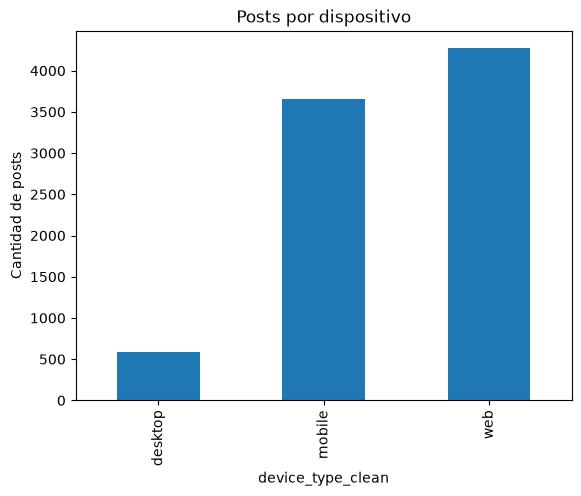

In [112]:

df_core.groupby('device_type_clean')['post_id'].count().plot(kind='bar', title='Posts por dispositivo')
plt.ylabel('Cantidad de posts')
plt.show()

Acción 2 (investigar el plan pro):

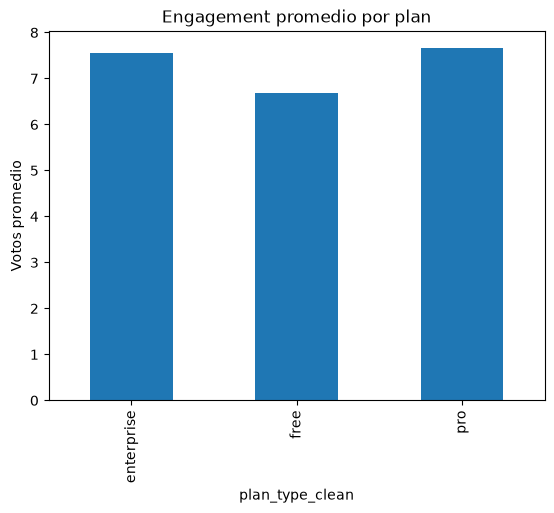

In [113]:
df_core.groupby('plan_type_clean')['votes_received'].mean().plot(kind='bar', title='Engagement promedio por plan')
plt.ylabel('Votos promedio')
plt.show()

## Conclusión
El dataset requirió limpieza moderada (3.1% de filas afectadas entre duplicados y quarantine), y reveló que la columna `days_since_signup` no era confiable. El segmento `pro` muestra el mejor engagement pese a su tamaño reducido, y la actividad está distribuida de forma relativamente pareja entre usuarios (el top 1% solo concentra ~6% de posts y votos).

In [114]:
df_core.to_csv('clean_product_activity.csv', index=False)
quarantine.to_csv('quarantine_product_activity.csv', index=False)


In [115]:
metrics_summary = pandas.DataFrame([
    # Data Quality
    {'metric': 'filas_raw', 'value': len(df)},
    {'metric': 'filas_core', 'value': len(df_core)},
    {'metric': 'pct_quarantine', 'value': round(len(quarantine) / len(df) * 100, 2)},
    {'metric': 'duplicados_removidos', 'value': total_duplicados},
    {'metric': 'pct_mismatch_fechas', 'value': round(no_coincide.sum() / len(df) * 100, 2)},

    # Usuarios por plan
    {'metric': 'usuarios_free', 'value': usuarios_por_plan.get('free', 0)},
    {'metric': 'usuarios_pro', 'value': usuarios_por_plan.get('pro', 0)},
    {'metric': 'usuarios_enterprise', 'value': usuarios_por_plan.get('enterprise', 0)},

    # Engagement por plan
    {'metric': 'votos_promedio_free', 'value': round(promedio_votos_por_plan.get('free', 0), 2)},
    {'metric': 'votos_promedio_pro', 'value': round(promedio_votos_por_plan.get('pro', 0), 2)},
    {'metric': 'votos_promedio_enterprise', 'value': round(promedio_votos_por_plan.get('enterprise', 0), 2)},

    # Evento vs usuario
    {'metric': 'promedio_votos_por_post', 'value': round(promedio_votos_por_fila, 2)},
    {'metric': 'promedio_votos_por_usuario', 'value': round(promedio_votos_por_usuario, 2)},
    {'metric': 'promedio_posts_por_usuario', 'value': round(posts_por_usuario.mean(), 2)},
    {'metric': 'mediana_posts_por_usuario', 'value': posts_por_usuario.median()},

    # Concentración
    {'metric': 'top1pct_usuarios_n', 'value': porcentaje_1},
    {'metric': 'top1pct_pct_posts', 'value': round(porc_posts * 100, 2)},
    {'metric': 'top1pct_pct_votos', 'value': round(porc_votos * 100, 2)},
])

metrics_summary.to_csv('metrics_summary.csv', index=False)
metrics_summary

,metric,value
0,filas_raw,8782.00
1,filas_core,8508.00
2,pct_quarantine,1.16
3,duplicados_removidos,172.00
4,pct_mismatch_fechas,51.00
5,usuarios_free,1545.00
6,usuarios_pro,367.00
7,usuarios_enterprise,83.00
8,votos_promedio_free,6.69
9,votos_promedio_pro,7.65
